# Does the euro area flinch when the ECB speaks? 🇪🇺🔔
### The ECB announcement effect — a market that gets **louder**, not more **predictable**

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Louder_not_more_directional%3F: Confirmed](https://img.shields.io/badge/Louder_not_more_directional%3F-Confirmed-8b949e?style=flat-square)

Eight times a year (monthly, before 2015), on a date published **months in advance**, the European Central Bank's Governing Council announces what it will do with interest rates. Traders on both sides of the Atlantic swear these days are special: the euro whips around, European stocks get choppy, and — the folklore says — you can lean on the direction of the move if you know it's coming.

We already know the Fed's version of this story is *real but unbankable* (see [637-fomc-vol-crush](../../637-fomc-vol-crush/) and [517-pre-fomc-drift](../../517-pre-fomc-drift/)). Does the ECB's own decision calendar do the same thing to euro-area equities?

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 208 scheduled decision dates (2005→2026) hardcoded from the ECB's own year-ahead schedule press releases — *scheduled* meetings only. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ecb_announcement_effect import data, strategy as st

ECB = data.ecb_calendar()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    FEZ, EURUSD = data.load_real()
    DF = st.day_frame(FEZ, EURUSD, ECB)
else:
    FEZ = EURUSD = DF = None
print("real cache present:", HAVE_REAL, "| scheduled ECB decisions:", len(ECB),
      "| tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'n_ecb': 207, 'n_rest': 5198, 'n_calendar': 208, 'cal_lo': '2005-01-13', 'cal_hi': '2026-06-11', 'ecb_pct': -0.103, 'rest_pct': 0.015, 'gap_pct': -0.118, 'welch_t': -0.82, 'nw_t': -0.83, 'hit': 114, 'hit_pct': 55.1, 'wilson': (48.3, 61.7), 'placebo_p': 0.345, 'placebo_mean': 0.0141, 'placebo_sd': 0.1093, 'placebo_draws': 20000, 'rng_ecb': 1.492, 'rng_rest': 1.257, 'rng_ratio': 1.19, 'rng_welch_t': 2.66, 'rng_nw_t': 2.83, 'rng_placebo_p': 0.0008, 'fx_ecb': 0.455, 'fx_rest': 0.436, 'fx_t': 0.65, 'event': {-5: (0.105, 0.85), -4: (-0.099, -1.1), -3: (-0.203, -1.58), -2: (0.171, 1.23), -1: (0.146, 1.11), 0: (-0.103, -0.84), 1: (0.017, -0.01), 2: (-0.112, -0.91), 3: (0.032, 0.12)}, 'runup_pct': 0.121, 'runup_t': 0.54, 'era_early': -0.137, 'era_early_n': 115, 'era_early_t': -0.66, 'era_late': -0.061, 'era_late_n': 92, 'era_late_t': -0.46, 'era_diff_t': 0.27, 'rng_era_early': 1.722, 'rng_era_early_t': 1.7, 'rng_era_late': 1.206, 'rng_era_late_t': 1.65, 'rng_era_diff_t': -3.18, 'tm_gross': -10.3, 'tm_net5': -20.3, 'tm_net10': -30.3, 'tm_net20': -50.3, 'tm_rest': 1.5, 'tm_t': -0.82, 'tm_ann5': -1.62, 'tm_ann10': -2.42, 'tm_ann20': -4.02, 'tm_n': 207, 'tm_hit': 55.1, 'tm_worst': -13.3, 'syn_null_mean': -0.07, 'syn_null_sd': 0.73, 'syn_null_fire': 0, 'syn_planted_t': 7.48, 'fp_fez': 'd1fc0178e274', 'fp_eurusd': 'c85271b5a68f'}


real cache present: True | scheduled ECB decisions: 208 | tape days: 5405


## The answer first

| Question | Answer |
|---|---|
| Does the euro-area stock market (FEZ) move a predictable *direction* on ECB day? | **No.** -0.12 points versus a normal day — statistically nothing (a random 207-day calendar beats it about a third of the time). |
| Is ECB day actually *quiet* then? | **No — it's louder.** FEZ's intraday high-low swing runs about **119%** bigger than normal — a real, measurable effect. The market moves *more*, just not in a knowable *direction*. |
| Does the euro (EURUSD) react more than stocks? | **Not measurably.** Its average absolute daily move on decision day is statistically the same as any other day. |
| Does the market ramp up *into* the decision, the way it does before a Fed meeting? | **No sign of it.** The five days before an ECB decision add up to **+0.12%** — noise. |
| Can you trade the day? | **No — it loses money before costs.** Holding FEZ just for the decision day nets **-10.3 bps/event gross**, before a single basis point of fee, with a **-13.3%** worst day. |

> Louder pulse, same coin flip.

## 1 · The claim

> *"The ECB is Europe's Fed. Its rate decisions carry real information — and just like Wall Street trades around FOMC day, European desks should see a systematic reaction: equities drift or jump on the news, the euro whips around, and the day is knowably different from any other Thursday."*

It's a reasonable steelman: the Governing Council sets the price of money for ~350 million people, on a calendar you can set your watch to, and the Fed's own version of this story turns out to be at least partly true (a real VIX crush, a real — if decayed — pre-meeting equity drift). Why wouldn't the ECB's decisions move markets the same way?

## 2 · So what?

If ECB decision days really do move euro-area equities in a predictable direction, that's a calendar-timed edge available to anyone with the schedule — no forecasting skill required, just discipline about which days to be long or short. And if the day is genuinely *louder* (even without a direction), that's still useful: it tells options desks where the event premium belongs, and it tells anyone managing risk which Thursdays deserve a smaller position.

So we ask three things: does FEZ move on ECB day, does it move *loudly*, and — the only question that actually pays — can you bank any of it after costs?

## 3 · How would we even know?

- **The calendar.** All **208** scheduled ECB decision dates from 2005-01-13 to 2026-06-11, hardcoded from the ECB's own year-ahead schedule announcements — monthly through 2014, then the now-familiar 6-week cycle from 2015.
- **The comparison.** FEZ's daily return and intraday swing on those **207** decision days vs the other **5,198** trading days.
- **The luck check.** Draw 207 random days instead, 20,000 times — how often does a random calendar produce a mean this large?
- **The trade check.** Buy FEZ at the close *before* the decision (the date is public months ahead — no crystal ball needed), sell at the decision-day close, pay costs.

## 4 · The teardown — let's actually look

**First, the headline.** Average FEZ return on decision days vs every other day.

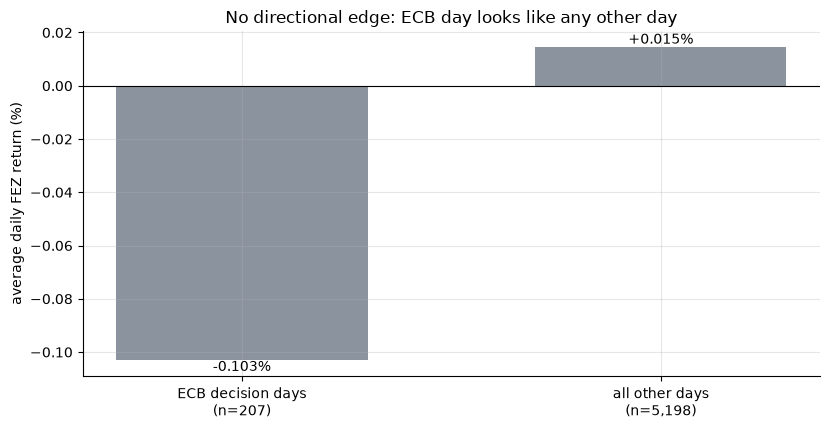

decision days -0.103%   other days +0.015%


In [2]:
if HAVE_REAL:
    s = st.decision_day_stats(DF)
    ep, rp = s['ecb_pct'], s['rest_pct']
else:
    ep, rp = R['ecb_pct'], R['rest_pct']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['ECB decision days\n(n=207)','all other days\n(n=5,198)'], [ep, rp],
       color=[GREY, GREY], width=.6)
for i,v in enumerate([ep, rp]): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average daily FEZ return (%)')
ax.set_title('No directional edge: ECB day looks like any other day')
plt.tight_layout(); plt.show()
print(f'decision days {ep:+.3f}%   other days {rp:+.3f}%')

Flat. **-0.103%** on the average decision day versus **+0.015%** on a normal one — the gap is well inside noise, and a random calendar of 207 days matches or beats it about a third of the time. **But** — and this is the interesting part — the day isn't *quiet*:

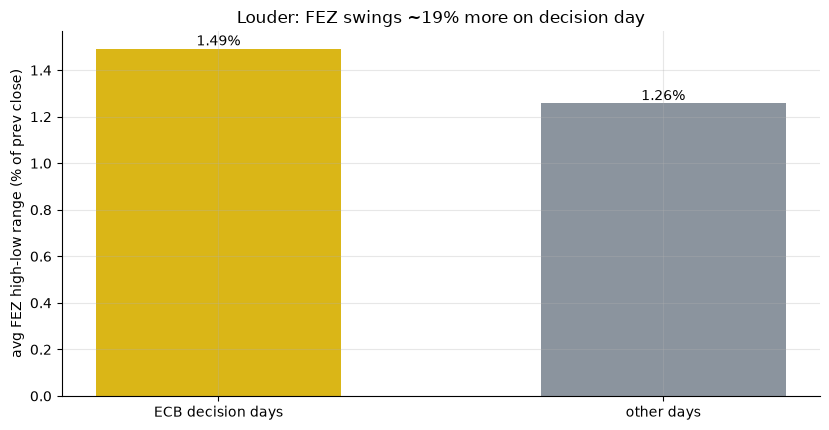

range: ECB days 1.492%  vs other 1.257%


In [3]:
if HAVE_REAL:
    rg = st.range_stats(DF)
    a, b = rg['ecb_range_pct'], rg['rest_range_pct']
else:
    a, b = R['rng_ecb'], R['rng_rest']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['ECB decision days','other days'], [a, b], color=[AMBER, GREY], width=.55)
for i,v in enumerate([a, b]): ax.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('avg FEZ high-low range (% of prev close)')
ax.set_title('Louder: FEZ swings ~19% more on decision day')
plt.tight_layout(); plt.show()
print(f'range: ECB days {a:.3f}%  vs other {b:.3f}%')

FEZ's intraday high-low swing runs **1.49%** on decision days versus **1.26%** normally — about **119%** bigger, and this one clears the statistical bar convincingly (the quants notebook has the full Welch/HAC/placebo breakdown). So the day genuinely *is* different — the market just can't tell you which way it'll go.

**What about the euro itself?**

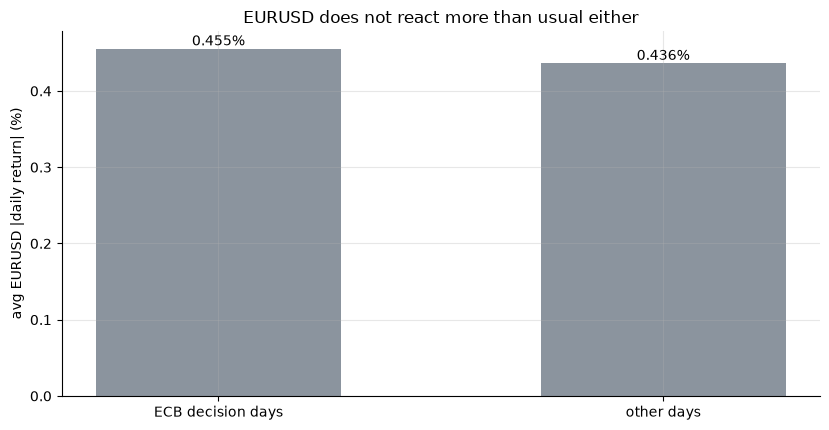

EURUSD |return|: ECB days 0.455%  vs other 0.436%


In [4]:
if HAVE_REAL:
    fx = st.eurusd_stats(DF)
    a, b = fx['ecb_abs_pct'], fx['rest_abs_pct']
else:
    a, b = R['fx_ecb'], R['fx_rest']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['ECB decision days','other days'], [a, b], color=[GREY, GREY], width=.55)
for i,v in enumerate([a, b]): ax.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('avg EURUSD |daily return| (%)')
ax.set_title('EURUSD does not react more than usual either')
plt.tight_layout(); plt.show()
print(f'EURUSD |return|: ECB days {a:.3f}%  vs other {b:.3f}%')

Surprising, but consistent: the currency doesn't whip around more than usual either. Whatever information the decision carries seems to already be priced in well before the press release — a point the quants notebook connects to how efficiently rate expectations trade in FX markets.

**Finally, the trade.** Can you bank the "louder day" by just holding FEZ through it?

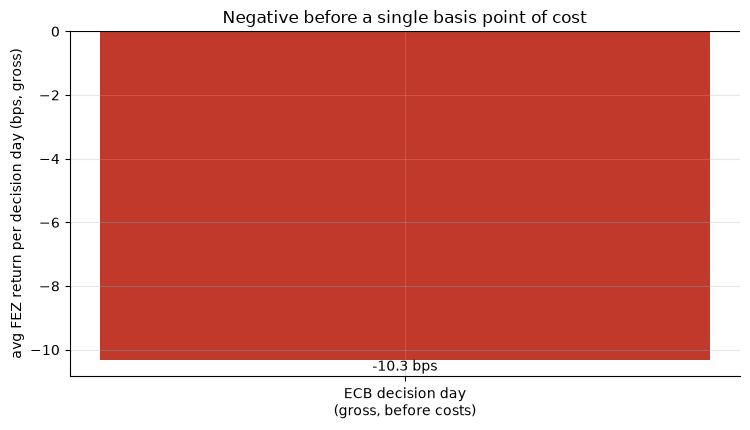

gross return per decision day: -10.3 bps


In [5]:
if HAVE_REAL:
    tc = st.timer_capture(DF, cost_bps=5.0)
    g = tc['gross_bps']
else:
    g = R['tm_gross']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['ECB decision day\n(gross, before costs)'], [g], color=RED, width=.45)
ax.annotate(f'{g:+.1f} bps',(0,g),ha='center',va='top' if g<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('avg FEZ return per decision day (bps, gross)')
ax.set_title('Negative before a single basis point of cost')
plt.tight_layout(); plt.show()
print(f'gross return per decision day: {g:+.1f} bps')

**-10.3 bps per event, gross** — negative before any cost is charged. Add the worst single day (**-13.3%**) and the picture is clear: there's no drift to harvest, and "the day is louder" doesn't help you if you don't know which way it'll be loud.

## 5 · The verdict

- **Signal — Mixed.** Real on the vol (FEZ genuinely swings **119%** more on decision day), **none** on the drift (no directional edge, no pre-meeting ramp, no extra EURUSD reaction).
- **Tradability — Mirage.** The only rule with a pulse loses money **before** costs.
- **"Louder, not more directional"? — Confirmed.** The ECB resolves uncertainty on decision day; it just doesn't resolve it in a predictable direction.

## 6 · Going further 🚪

- **The general lesson travels.** Scheduled macro announcements load a vol premium into the surface that must expire once the news is out — the ECB is just one more instance, alongside the Fed ([637](../../637-fomc-vol-crush/)) and OPEC ([606](../../606-opec-announcement-effect/)): louder day, coin-flip direction, no drift to bank in the underlying.
- **Where the pros actually play it** is the *options* on decision day (the vol premium itself), not a directional bet on the ETF.
- **Sibling studies:** the [Fed's own vol crush](../../637-fomc-vol-crush/), its [pre-meeting equity drift](../../517-pre-fomc-drift/) and [OPEC's version](../../606-opec-announcement-effect/) of exactly this same real-vol/no-drift finding — none of them is this study: euro-area equities, on the ECB's own calendar.

*Think the euro-area reaction hides inside a shorter window than a daily bar can see? Show a net, certifiable intraday edge — after the market-maker's spread on ECB afternoons — then we'll talk.*